In [6]:
# ---------------------------
# Core Libraries
# ---------------------------
import os
import re
import string
import joblib
import numpy as np
import pandas as pd

# ---------------------------
# Visualization
# ---------------------------
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from scipy.special import expit  # sigmoid
# ---------------------------
# NLP Libraries
# ---------------------------
import nltk
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag, word_tokenize
from nltk.util import ngrams
from wordcloud import WordCloud

# ---------------------------
# Machine Learning
# ---------------------------
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve,
    auc
)
from sklearn.preprocessing import label_binarize

# ---------------------------
# Utilities
# ---------------------------
from tqdm import tqdm
from imblearn.over_sampling import RandomOverSampler


from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeClassifier
from sklearn.preprocessing import StandardScaler
import joblib
import os
from sklearn.tree import DecisionTreeClassifier
import joblib
import os
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import ExtraTreesClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
import joblib
import os
import joblib
import os


In [7]:
MODEL_DIR = "models"
RESULT_DIR = "results"
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(RESULT_DIR, exist_ok=True)

In [8]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\admin\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\admin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\admin\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\admin\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


True

In [10]:
df = pd.read_csv(r"mental_heath_unbanlanced.csv")
df

,text,status
0,oh my gosh,Anxiety
1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,I've shifted my focus to something else but I'...,Anxiety
4,"I'm restless and restless, it's been a month n...",Anxiety
...,...,...
49609,i can't explain it but i know that i don't wan...,Depression
49610,nobody ever told me that when i started treatm...,Depression
49611,my wife and i split up in 2012/2013. she had a...,Depression
49612,A close family member committed suicideI just ...,Suicidal


In [11]:
df['status'].value_counts()

status
Normal        18390
Depression    14506
Suicidal      11211
Anxiety        5503
Name: count, dtype: int64

In [12]:
categories = df["status"].unique()
y=df['status']
categories

array(['Anxiety', 'Normal', 'Depression', 'Suicidal', nan], dtype=object)

In [13]:
def eda_nlp_analysis(X_text, num_words=100, top_n_words=20):
    """
    Perform NLP EDA:
        1. WordCloud
        2. Top N words
        3. Document length histogram
        4. POS tag frequency
        5. Bigram frequency

    Parameters:
        X_text (list of str): Input preprocessed text data.
        num_words (int): Number of words to show in word cloud.
        top_n_words (int): Number of top frequent words to plot.
    """
    print("Generating NLP EDA Visualizations...")

    # Flatten all tokens from all texts
    all_tokens = [word for doc in X_text for word in word_tokenize(doc)]

    # --- 1. WordCloud ---
    word_freq = Counter(all_tokens)
    wc = WordCloud(width=800, height=400, max_words=num_words, background_color='white').generate_from_frequencies(word_freq)

    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"Top {num_words} Words - WordCloud")
    plt.show()

    # --- 2. Top-N Frequent Words ---
    common_words = word_freq.most_common(top_n_words)
    words, counts = zip(*common_words)
    plt.figure(figsize=(10, 5))
    sns.barplot(x=list(counts), y=list(words), palette="viridis")
    plt.title(f"Top {top_n_words} Most Frequent Words")
    plt.xlabel("Count")
    plt.ylabel("Word")
    plt.show()

    # --- 3. Document Length Histogram ---
    doc_lengths = [len(word_tokenize(doc)) for doc in X_text]
    plt.figure(figsize=(10, 5))
    sns.histplot(doc_lengths, bins=20, kde=True, color='teal')
    plt.title("Distribution of Document Lengths (in words)")
    plt.xlabel("Number of Words per Document")
    plt.ylabel("Frequency")
    plt.show()

    # --- 4. POS Tag Frequency ---
    all_pos = [tag for _, tag in pos_tag(all_tokens)]
    pos_counts = Counter(all_pos).most_common()
    pos_tags, pos_freqs = zip(*pos_counts)
    plt.figure(figsize=(10, 5))
    sns.barplot(x=list(pos_tags), y=list(pos_freqs), palette="coolwarm")
    plt.title("Part of Speech (POS) Tag Frequency")
    plt.xlabel("POS Tag")
    plt.ylabel("Frequency")
    plt.xticks(rotation=45)
    plt.show()

    # --- 5. Bigram Frequency Plot ---
    bigrams = list(ngrams(all_tokens, 2))
    bigram_freq = Counter(bigrams).most_common(top_n_words)
    bigram_labels = [' '.join(b) for b, _ in bigram_freq]
    bigram_counts = [count for _, count in bigram_freq]

    plt.figure(figsize=(10, 5))
    sns.barplot(x=bigram_counts, y=bigram_labels, palette="magma")
    plt.title(f"Top {top_n_words} Bigrams")
    plt.xlabel("Count")
    plt.ylabel("Bigram")
    plt.show()


In [15]:
df["text"] = df["text"].fillna("").astype(str)

Generating NLP EDA Visualizations...


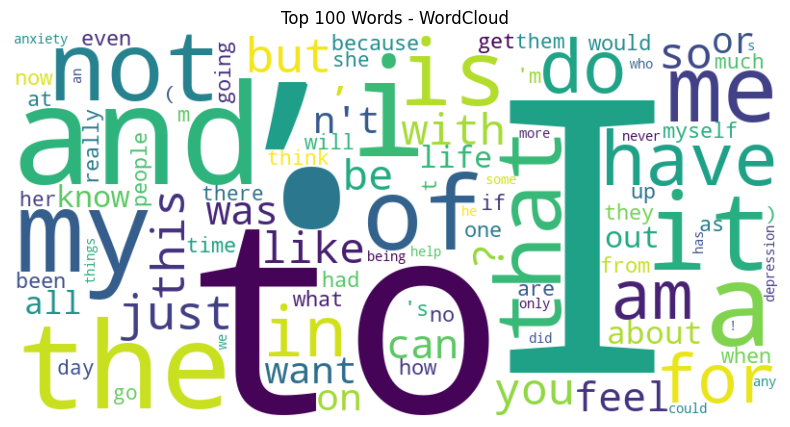

C:\Users\admin\AppData\Local\Temp\ipykernel_13368\1063056502.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts), y=list(words), palette="viridis")


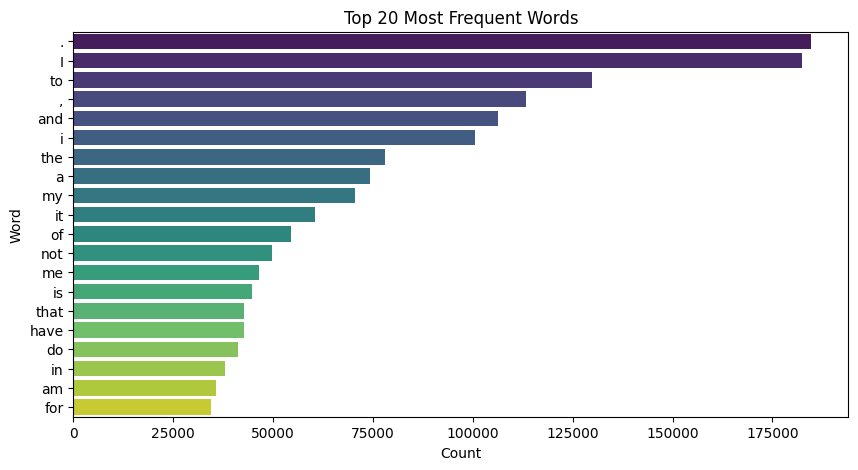

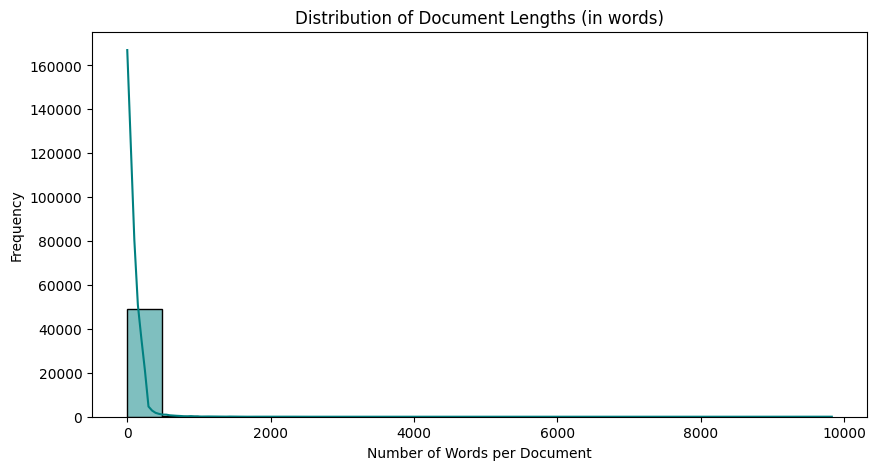

C:\Users\admin\AppData\Local\Temp\ipykernel_13368\1063056502.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(pos_tags), y=list(pos_freqs), palette="coolwarm")


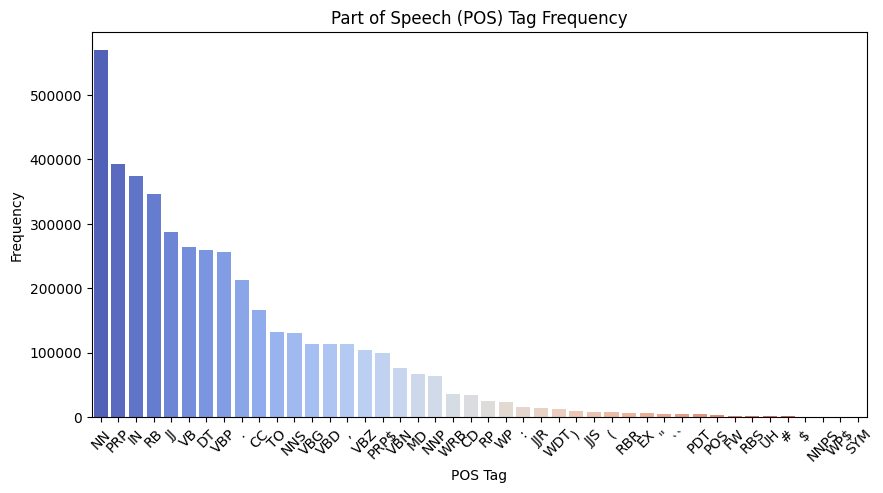

C:\Users\admin\AppData\Local\Temp\ipykernel_13368\1063056502.py:68: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=bigram_counts, y=bigram_labels, palette="magma")


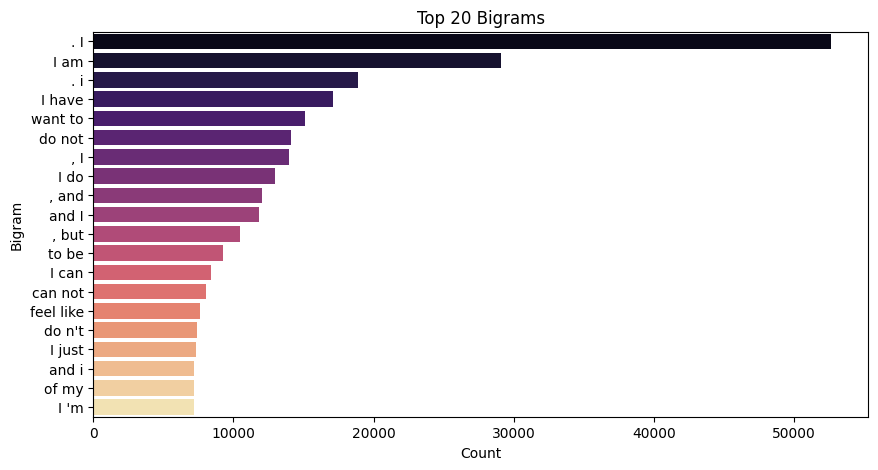

In [16]:
eda_nlp_analysis(X_text=df["text"], num_words=100, top_n_words=20)

In [17]:

tqdm.pandas(desc="Text Preprocessing")


stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()


def preprocess_text_full(text):

    text = str(text)
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"[^a-zA-Z0-9' ]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    text = text.lower()
    text = text.translate(str.maketrans("", "", string.punctuation))

    tokens = word_tokenize(text)

    pos_tags = pos_tag(tokens)

    def get_wordnet_pos(tag):
        if tag.startswith('J'):
            return wordnet.ADJ
        elif tag.startswith('V'):
            return wordnet.VERB
        elif tag.startswith('N'):
            return wordnet.NOUN
        elif tag.startswith('R'):
            return wordnet.ADV
        return wordnet.NOUN

    lemmas = [
        lemmatizer.lemmatize(word, get_wordnet_pos(tag))
        for word, tag in pos_tags
        if word not in stop_words and word.strip() != ""
    ]

    return " ".join(lemmas)

In [18]:
df["clean_text"] = df["text"].progress_apply(preprocess_text_full)

Text Preprocessing: 100%|███████████████████████████████████████████████████████| 49614/49614 [04:30<00:00, 183.40it/s]


In [19]:
df

,text,status,clean_text
0,oh my gosh,Anxiety,oh gosh
1,"trouble sleeping, confused mind, restless hear...",Anxiety,trouble sleep confuse mind restless heart tune
2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety,wrong back dear forward doubt stay restless re...
3,I've shifted my focus to something else but I'...,Anxiety,ive shift focus something else im still worry
4,"I'm restless and restless, it's been a month n...",Anxiety,im restless restless month boy mean
...,...,...,...
49609,i can't explain it but i know that i don't wan...,Depression,cant explain know dont want live anymore dont ...
49610,nobody ever told me that when i started treatm...,Depression,nobody ever tell start treatment theyd take ho...
49611,my wife and i split up in 2012/2013. she had a...,Depression,wife split 2012 2013 daughter previous relatio...
49612,A close family member committed suicideI just ...,Suicidal,close family member commit suicidei find day a...


In [20]:
df.drop(columns=["text"], inplace=True)

In [21]:
df

,status,clean_text
0,Anxiety,oh gosh
1,Anxiety,trouble sleep confuse mind restless heart tune
2,Anxiety,wrong back dear forward doubt stay restless re...
3,Anxiety,ive shift focus something else im still worry
4,Anxiety,im restless restless month boy mean
...,...,...
49609,Depression,cant explain know dont want live anymore dont ...
49610,Depression,nobody ever tell start treatment theyd take ho...
49611,Depression,wife split 2012 2013 daughter previous relatio...
49612,Suicidal,close family member commit suicidei find day a...


In [22]:
def extract_text_features(text):
    tokens = text.split()

    if len(tokens) == 0:
        return pd.Series([0]*10)

    return pd.Series([
        len(tokens),                                      # word count
        len(text),                                        # char count
        np.mean([len(w) for w in tokens]),                # avg word length
        np.std([len(w) for w in tokens]),                 # std word length
        sum(w.isupper() for w in tokens),                 # uppercase words
        sum(any(c.isdigit() for c in w) for w in tokens), # digit words
        sum(w.isalpha() for w in tokens),                 # alphabetic words
        len(set(tokens)),                                 # unique words
        len(set(tokens)) / len(tokens),                   # lexical diversity
        sum(len(w) > 6 for w in tokens)                   # long words
    ])

stat_features = df["clean_text"].progress_apply(extract_text_features)
stat_features.columns = [
    "word_count", "char_count", "avg_word_len", "std_word_len",
    "upper_words", "digit_words", "alpha_words",
    "unique_words", "lexical_diversity", "long_words"
]

Text Preprocessing: 100%|██████████████████████████████████████████████████████| 49614/49614 [00:15<00:00, 3263.01it/s]


In [23]:
stat_features

,word_count,char_count,avg_word_len,std_word_len,upper_words,digit_words,alpha_words,unique_words,lexical_diversity,long_words
0,2.0,7.0,3.000000,1.000000,0.0,0.0,2.0,2.0,1.000000,0.0
1,7.0,46.0,5.714286,1.484615,0.0,0.0,7.0,7.0,1.000000,3.0
2,9.0,58.0,5.555556,1.571348,0.0,0.0,9.0,8.0,0.888889,3.0
3,8.0,45.0,4.750000,1.920286,0.0,0.0,8.0,8.0,1.000000,1.0
4,6.0,35.0,5.000000,2.309401,0.0,0.0,6.0,5.0,0.833333,2.0
...,...,...,...,...,...,...,...,...,...,...
49609,36.0,210.0,4.861111,1.988198,0.0,1.0,35.0,28.0,0.777778,9.0
49610,75.0,422.0,4.640000,1.873606,0.0,0.0,75.0,46.0,0.613333,10.0
49611,337.0,2031.0,5.029674,1.966864,0.0,16.0,321.0,240.0,0.712166,63.0
49612,55.0,326.0,4.945455,1.611529,0.0,0.0,55.0,49.0,0.890909,8.0


In [24]:
le = LabelEncoder()
y = le.fit_transform(df['status'])

In [25]:
y

array([0, 0, 0, ..., 1, 3, 0])

In [26]:
vectorizer = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    min_df=3
)

X_text = vectorizer.fit_transform(df["clean_text"])


In [27]:
svd = TruncatedSVD(n_components=300, random_state=42)
X_text_svd = svd.fit_transform(X_text)

stdscaler = StandardScaler()
X_text_svd = stdscaler.fit_transform(X_text_svd)


In [28]:
X_final = np.hstack([
    X_text_svd,
    stat_features.values
])

In [29]:
X_final

array([[-1.48374371e+00,  1.08956069e-01, -4.71391130e-02, ...,
         2.00000000e+00,  1.00000000e+00,  0.00000000e+00],
       [-1.15414351e+00,  3.62717664e-01,  8.62119214e-02, ...,
         7.00000000e+00,  1.00000000e+00,  3.00000000e+00],
       [-1.04792647e+00,  3.52759822e-01,  3.19977122e-02, ...,
         8.00000000e+00,  8.88888889e-01,  3.00000000e+00],
       ...,
       [ 1.89147258e+00,  2.78214739e-01, -1.36492739e-01, ...,
         2.40000000e+02,  7.12166172e-01,  6.30000000e+01],
       [ 1.09446598e+00, -1.16121931e+00, -1.17272189e-01, ...,
         4.90000000e+01,  8.90909091e-01,  8.00000000e+00],
       [ 2.00422180e+00,  1.69069578e+00, -2.20712783e-01, ...,
         1.32000000e+02,  7.67441860e-01,  3.50000000e+01]])

In [30]:
y

array([0, 0, 0, ..., 1, 3, 0])

In [31]:

ros = RandomOverSampler(random_state=42)
X_balanced, y_balanced = ros.fit_resample(X_final, y)


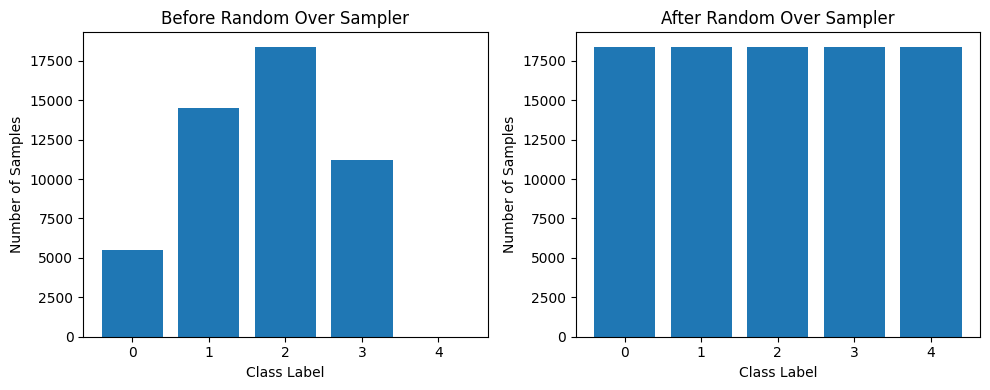

In [32]:
y_before = pd.Series(y)
before_counts = y_before.value_counts().sort_index()

y_after = pd.Series(y_balanced)
after_counts = y_after.value_counts().sort_index()


fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Before SMOTE
axes[0].bar(before_counts.index.astype(str), before_counts.values)
axes[0].set_title("Before Random Over Sampler")
axes[0].set_xlabel("Class Label")
axes[0].set_ylabel("Number of Samples")

# After SMOTE
axes[1].bar(after_counts.index.astype(str), after_counts.values)
axes[1].set_title("After Random Over Sampler")
axes[1].set_xlabel("Class Label")
axes[1].set_ylabel("Number of Samples")

plt.tight_layout()
plt.show()


In [33]:
X_train, X_test, y_train, y_test = train_test_split(X_balanced, y_balanced,test_size=0.2,random_state=42, stratify=y_balanced)

In [34]:

cls_names = []
Accuracy_list = []
Precision_list = []
Recall_list = []
F1_list = []
AUC_list = []
     

def calculateMetrics(algorithm, preds, y_test, probs=None, save_dir="results"):

    os.makedirs(save_dir, exist_ok=True)

    if isinstance(y_test, np.ndarray) and y_test.ndim > 1:
        y_test = np.argmax(y_test, axis=1)

    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds, average="weighted", zero_division=0)
    rec = recall_score(y_test, preds, average="weighted", zero_division=0)
    f1 = f1_score(y_test, preds, average="weighted", zero_division=0)

    if probs is not None and probs.ndim == 2:
        try:
            auc_score = roc_auc_score(y_test, probs, multi_class="ovr")
        except:
            auc_score = np.nan
    else:
        auc_score = np.nan

    cls_names.append(algorithm)
    Accuracy_list.append(acc)
    Precision_list.append(prec)
    Recall_list.append(rec)
    F1_list.append(f1)
    AUC_list.append(auc_score)

    print(algorithm)
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")
    if not np.isnan(auc_score):
        print(f"AUC      : {auc_score:.4f}")
    print("-" * 40)

    # -------- Confusion Matrix --------
    cm = confusion_matrix(y_test, preds)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix - {algorithm}")
    plt.tight_layout()
    plt.savefig(f"{save_dir}/{algorithm}_confusion_matrix.png")
    plt.show()
    plt.close()

In [35]:
def plot_classification_comparison(save_dir="results"):
    os.makedirs(save_dir, exist_ok=True)

    min_len = min(
        len(cls_names),
        len(Accuracy_list),
        len(Precision_list),
        len(Recall_list),
        len(F1_list),
        len(AUC_list)
    )

    x = np.arange(min_len)
    width = 0.15

    plt.figure(figsize=(14, 6))
    plt.bar(x - 2*width, Accuracy_list[:min_len], width, label="Accuracy")
    plt.bar(x - width, Precision_list[:min_len], width, label="Precision")
    plt.bar(x, Recall_list[:min_len], width, label="Recall")
    plt.bar(x + width, F1_list[:min_len], width, label="F1-score")
    plt.bar(x + 2*width, AUC_list[:min_len], width, label="AUC")

    plt.xticks(x, cls_names[:min_len], rotation=20)
    plt.ylabel("Score")
    plt.title("Classification Model Comparison")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"{save_dir}/classification_comparison.png")
    plt.show()
    plt.close()


Ridge Classifier
Accuracy : 0.7862
Precision: 0.7836
Recall   : 0.7862
F1-score : 0.7806
----------------------------------------


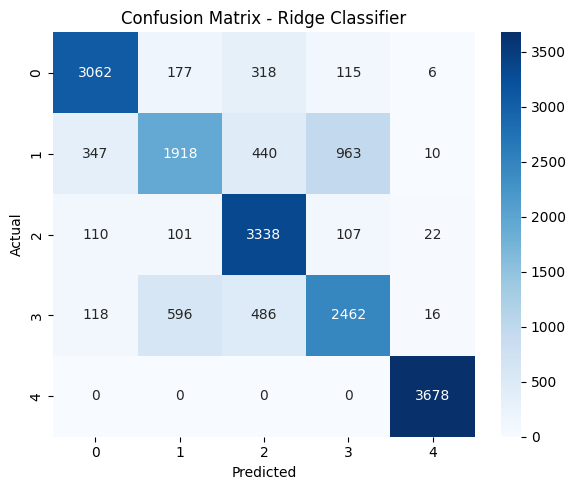

In [36]:
# Ridge works better with StandardScaler (not MinMax)
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

ridge_model = RidgeClassifier(random_state=42)
ridge_model.fit(X_train_scaled, y_train)

joblib.dump(ridge_model, os.path.join(MODEL_DIR, "ridge_classifier.pkl"))

y_pred_ridge = ridge_model.predict(X_test_scaled)

calculateMetrics("Ridge Classifier", y_pred_ridge, y_test)


Decision Tree
Accuracy : 0.8401
Precision: 0.8383
Recall   : 0.8401
F1-score : 0.8378
----------------------------------------


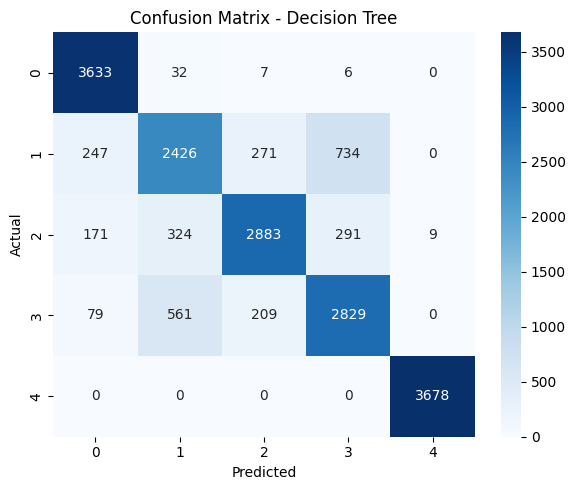

In [37]:
# Decision Trees do NOT require feature scaling
dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

joblib.dump(dt_model, os.path.join(MODEL_DIR, "decision_tree.pkl"))

y_pred_dt = dt_model.predict(X_test)

calculateMetrics("Decision Tree", y_pred_dt, y_test)


Logistic Regression
Accuracy : 0.8067
Precision: 0.8040
Recall   : 0.8067
F1-score : 0.8047
----------------------------------------


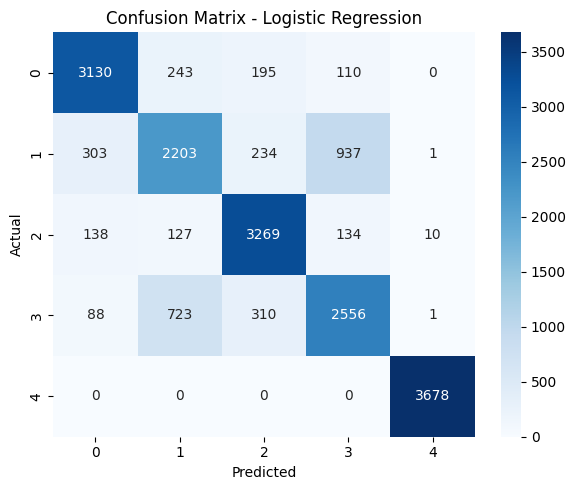

In [38]:

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

log_model = LogisticRegression(random_state=42, max_iter=1000)

log_model.fit(X_train_scaled, y_train)

joblib.dump(log_model, os.path.join(MODEL_DIR, "logistic_regression.pkl"))

y_pred_log = log_model.predict(X_test_scaled)

calculateMetrics("Logistic Regression", y_pred_log, y_test)


ExtraTrees + XGBoost Stacking
Accuracy : 0.9077
Precision: 0.9078
Recall   : 0.9077
F1-score : 0.9076
----------------------------------------


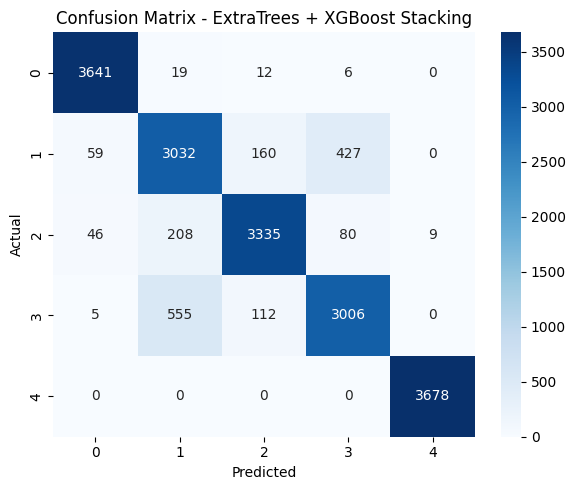

In [39]:
# Create model directory
os.makedirs(MODEL_DIR, exist_ok=True)

# -------------------------------
# Base Models
# -------------------------------

extra_model = ExtraTreesClassifier(
    n_estimators=500,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

xgb_model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=42
)

# -------------------------------
# Stacking Model
# -------------------------------

stack_model = StackingClassifier(
    estimators=[
        ('extra', extra_model),
        ('xgb', xgb_model)
    ],
    final_estimator=LogisticRegression(),
    cv=5,
    n_jobs=-1
)

# Train
stack_model.fit(X_train, y_train)

# Save
joblib.dump(stack_model, os.path.join(MODEL_DIR, "stack_extra_xgb.pkl"))

# Predict
y_pred_stack = stack_model.predict(X_test)

# Evaluate
calculateMetrics("ExtraTrees + XGBoost Stacking", y_pred_stack, y_test)


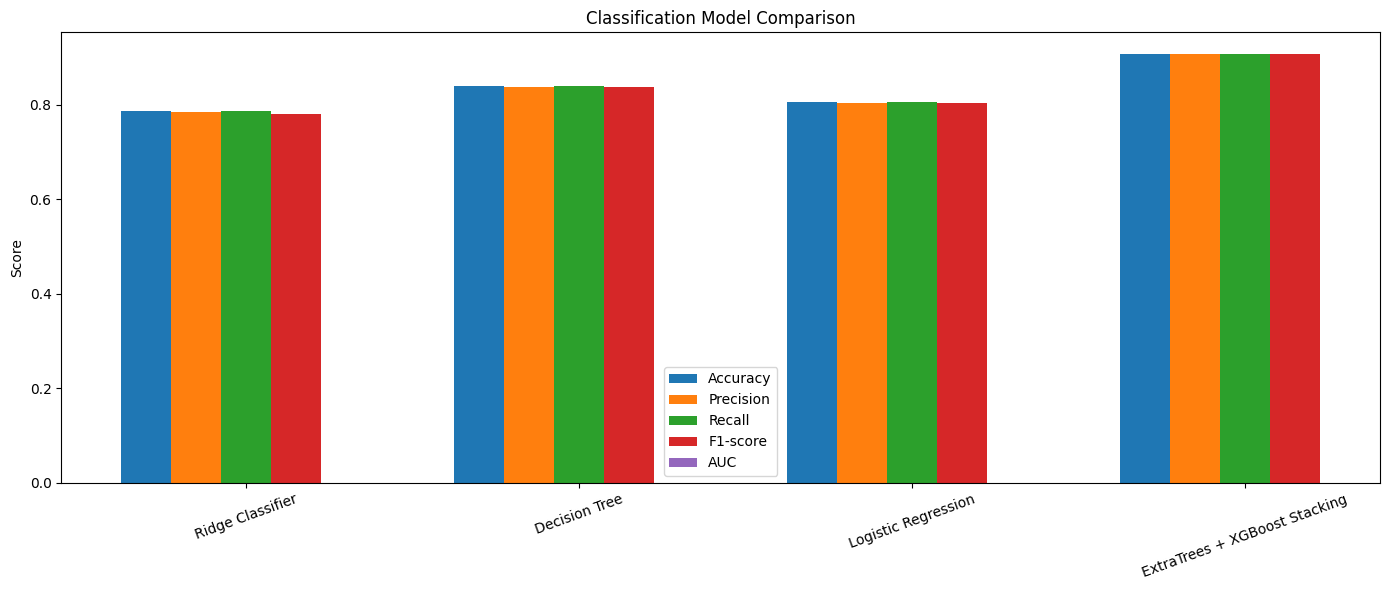

In [40]:
plot_classification_comparison()

In [50]:
test_df = pd.read_csv(r"test.csv")
test_df

,text
0,oh my gosh
1,"trouble sleeping, confused mind, restless hear..."
2,"All wrong, back off dear, forward doubt. Stay ..."
3,I've shifted my focus to something else but I'...
4,"I'm restless and restless, it's been a month n..."
5,"every break, you must be nervous, like somethi..."
6,"I feel scared, anxious, what can I do? And may..."
7,Have you ever felt nervous but didn't know why?
8,I recently went through a breakup and she said...
9,"So I have been with my bf for 5 months , and h..."


In [51]:
test_df["clean_text"] = test_df["text"].progress_apply(preprocess_text_full)

Text Preprocessing: 100%|██████████████████████████████████████████████████████████████| 30/30 [00:00<00:00, 41.34it/s]


In [52]:
test_df.drop(columns=["text"], inplace=True)

In [53]:
stat_features = test_df["clean_text"].progress_apply(extract_text_features)
stat_features.columns = [
    "word_count", "char_count", "avg_word_len", "std_word_len",
    "upper_words", "digit_words", "alpha_words",
    "unique_words", "lexical_diversity", "long_words"
]

Text Preprocessing: 100%|████████████████████████████████████████████████████████████| 30/30 [00:00<00:00, 1503.75it/s]


In [54]:
X_text_test_df = vectorizer.transform(test_df["clean_text"])

In [55]:
X_text_svd_test1 = svd.transform(X_text_test_df)
X_text_svd_test = stdscaler.transform(X_text_svd_test1)

In [56]:
X_final_test = np.hstack([
    X_text_svd_test,
    stat_features.values
])

In [57]:
y_pred = stack_model.predict(X_final_test)

In [58]:
results_df = test_df.copy()
results_df["Predicted_status"] = y_pred
results_df

,clean_text,Predicted_status
0,oh gosh,0
1,trouble sleep confuse mind restless heart tune,0
2,wrong back dear forward doubt stay restless re...,0
3,ive shift focus something else im still worry,0
4,im restless restless month boy mean,0
5,every break must nervous like something wrong ...,0
6,feel scar anxious may family u protect,0
7,ever felt nervous didnt know,0
8,recently go breakup say still want friend say ...,1
9,bf 5 month already tell depress week nothing p...,1
